# **Load Needed Libraries and Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
from imblearn.over_sampling import SMOTE
import json
import joblib
warnings.filterwarnings("ignore")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

100%|██████████| 172k/172k [00:00<00:00, 301kB/s]

Extracting files...
Path to dataset files: C:\Users\maria\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
Churn_df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
Churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Verify column names
print("Column Names:")
print(Churn_df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


# **1.Data Preprocessing**

In [5]:
#data Info
print("Dataset Shape:", Churn_df.shape)
Churn_df.info()

Dataset Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

In [6]:
#Get null/garbage & duplicated values
print('the null values = ',Churn_df.isnull().sum())
print('the duplicates  = ',Churn_df.duplicated().sum())
print('finding the garbage values')
for i in Churn_df.select_dtypes(include="object").columns:
    print(Churn_df[i].value_counts())
    print("***"*10)

the null values =  customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
the duplicates  =  0
finding the garbage values
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
******************************
gender
Male      3555
Female    3488
Name: count, dtype: int64
******************************
Partner
No     3641
Yes    3402
Name: count, dtype: int64
******************************
Dependents
No    

In [7]:
# Uniques
print("\nUnique Values per Column:")
for col in Churn_df.columns:
    print(f"Column: {col}")
    print(Churn_df[col].unique())
    print("---------------")


Unique Values per Column:
Column: customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
---------------
Column: gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
---------------
Column: SeniorCitizen
[0 1]
---------------
Column: Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
---------------
Column: Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
---------------
Column: tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
---------------
Column: PhoneService
<StringArray>
['No', 'Yes']
Length: 2

In [8]:
# Fix TotalCharges - convert to numeric, fill blanks with 0
Churn_df['TotalCharges'] = pd.to_numeric(Churn_df['TotalCharges'], errors='coerce')
print("NaN count after conversion:", Churn_df['TotalCharges'].isnull().sum())

Churn_df['TotalCharges'] = Churn_df['TotalCharges'].fillna(0)
print("NaN count after fill:", Churn_df['TotalCharges'].isnull().sum())

NaN count after conversion: 11
NaN count after fill: 0


In [9]:
# Check who has the blank TotalCharges
mask = Churn_df['TotalCharges'].isnull()
print(Churn_df[mask][['tenure', 'MonthlyCharges', 'TotalCharges']])

Empty DataFrame
Columns: [tenure, MonthlyCharges, TotalCharges]
Index: []


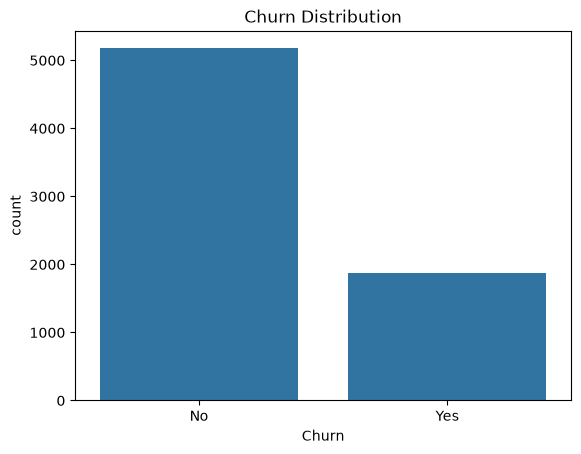

In [10]:
#See Imbalanced classes
sns.countplot(x='Churn', data=Churn_df)
plt.title('Churn Distribution')
plt.show()

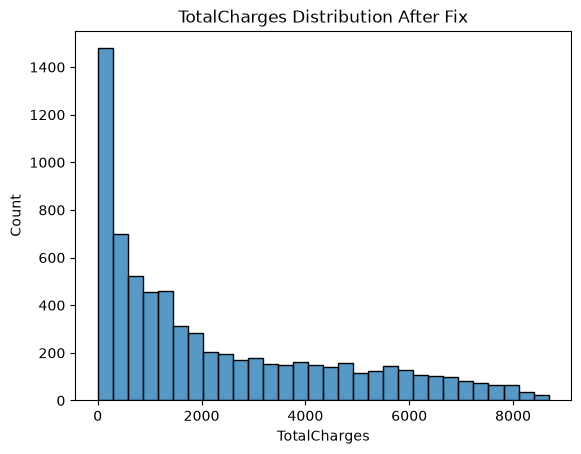

In [11]:
#check Totalcharge after fix
sns.histplot(Churn_df['TotalCharges'], bins=30)
plt.title('TotalCharges Distribution After Fix')
plt.show()

# **2.Feature Extraction using SQL**

In [12]:
import sqlite3
conn = sqlite3.connect(':memory:')
Churn_df.to_sql('customers', conn, index=False, if_exists='replace')
print("Data loaded into SQLite successfully")

Data loaded into SQLite successfully


**Query 1 : what % of customers are actually churning**

In [13]:
q1 = pd.read_sql("""
    SELECT Churn,
           COUNT(*) AS total_customers,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) AS percentage
    FROM customers
    GROUP BY Churn
""", conn)
print("── Query 1: Overall Churn Rate ──")
print(q1)

── Query 1: Overall Churn Rate ──
  Churn  total_customers  percentage
0    No             5174       73.46
1   Yes             1869       26.54


**Query 2 : Identify if contract type is a strong business driver of churn**

In [14]:
q2 = pd.read_sql("""
    SELECT Contract,
           COUNT(*) AS total_customers,
           SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
           ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY Contract
    ORDER BY churn_rate_pct DESC
""", conn)
print("── Query 2: Churn Rate by Contract Type ──")
print(q2)

── Query 2: Churn Rate by Contract Type ──
         Contract  total_customers  churned  churn_rate_pct
0  Month-to-month             3875     1655           42.71
1        One year             1473      166           11.27
2        Two year             1695       48            2.83


**Query 3 : Check if the type of internet service affects churn**

In [15]:
q3 = pd.read_sql("""
    SELECT InternetService,
           COUNT(*) AS total_customers,
           SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
           ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY InternetService
    ORDER BY churn_rate_pct DESC
""", conn)
print("── Query 3: Churn Rate by Internet Service ──")
print(q3)

── Query 3: Churn Rate by Internet Service ──
  InternetService  total_customers  churned  churn_rate_pct
0     Fiber optic             3096     1297           41.89
1             DSL             2421      459           18.96
2              No             1526      113            7.40


**Query 4 : do churners pay more or less on average**

In [16]:
q4 = pd.read_sql("""
    SELECT Churn,
           ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
           ROUND(AVG(TotalCharges), 2)   AS avg_total_charges,
           ROUND(AVG(tenure), 2)         AS avg_tenure_months
    FROM customers
    GROUP BY Churn
""", conn)
print("── Query 4: Average Charges by Churn Status ──")
print(q4)

── Query 4: Average Charges by Churn Status ──
  Churn  avg_monthly_charges  avg_total_charges  avg_tenure_months
0    No                61.27            2549.91              37.57
1   Yes                74.44            1531.80              17.98


**Query 5 : Extract the most vulnerable customer segment**

In [17]:
q5 = pd.read_sql("""
    SELECT customerID, tenure, MonthlyCharges, Contract, Churn
    FROM customers
    WHERE tenure < 12
      AND Contract = 'Month-to-month'
      AND MonthlyCharges > 70
    ORDER BY MonthlyCharges DESC
""", conn)
print("── Query 5: High Risk Customers ──")
print(q5.head(10))

── Query 5: High Risk Customers ──
   customerID  tenure  MonthlyCharges        Contract Churn
0  3292-PBZEJ      11          111.40  Month-to-month    No
1  9851-KIELU      10          110.10  Month-to-month   Yes
2  3992-YWPKO       6          109.90  Month-to-month   Yes
3  5760-IFJOZ       3          107.95  Month-to-month    No
4  2081-VEYEH       3          107.95  Month-to-month    No
5  1400-MMYXY       3          105.90  Month-to-month   Yes
6  3389-YGYAI       8          105.50  Month-to-month   Yes
7  5052-PNLOS       3          105.35  Month-to-month   Yes
8  6734-GMPVK       5          105.30  Month-to-month    No
9  4587-VVTOX       6          105.30  Month-to-month   Yes


**Query 6 : Check if payment method correlates with churn**

In [18]:
q6 = pd.read_sql("""
    SELECT PaymentMethod,
           COUNT(*) AS total_customers,
           SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
           ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY PaymentMethod
    ORDER BY churn_rate_pct DESC
""", conn)
print("── Query 6: Churn Rate by Payment Method ──")
print(q6)

── Query 6: Churn Rate by Payment Method ──
               PaymentMethod  total_customers  churned  churn_rate_pct
0           Electronic check             2365     1071           45.29
1               Mailed check             1612      308           19.11
2  Bank transfer (automatic)             1544      258           16.71
3    Credit card (automatic)             1522      232           15.24


**Query 7 : Check if being a senior citizen is a risk factor for churn**

In [19]:
q7 = pd.read_sql("""
    SELECT SeniorCitizen,
           COUNT(*) AS total_customers,
           SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
           ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY SeniorCitizen
""", conn)
print("── Query 7: Senior Citizens Churn Rate ──")
print(q7)

── Query 7: Senior Citizens Churn Rate ──
   SeniorCitizen  total_customers  churned  churn_rate_pct
0              0             5901     1393           23.61
1              1             1142      476           41.68


**Query 8 : create a new feature counting**

-how many add-on services each customer has subscribed to.

-More services = more engaged = less likely to churn.

In [20]:
q8 = pd.read_sql("""
    SELECT customerID,
           Churn,
           (CASE WHEN PhoneService    = 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN MultipleLines   = 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN OnlineSecurity  = 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN OnlineBackup    = 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN DeviceProtection= 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN TechSupport     = 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN StreamingTV     = 'Yes' THEN 1 ELSE 0 END +
            CASE WHEN StreamingMovies = 'Yes' THEN 1 ELSE 0 END) AS total_services
    FROM customers
    ORDER BY total_services DESC
""", conn)
print("── Query 8: Number of Services per Customer ──")
print(q8.head(10))

── Query 8: Number of Services per Customer ──
   customerID Churn  total_services
0  3655-SNQYZ    No               8
1  5248-YGIJN    No               8
2  3146-MSEGF    No               8
3  5997-OPVFA    No               8
4  7017-VFHAY    No               8
5  6655-LHBYW    No               8
6  1950-KSVVJ    No               8
7  0123-CRBRT    No               8
8  1557-EMYVT    No               8
9  2088-IEBAU    No               8


In [21]:
#mearge query 8 result to the churn_df as new feature
Churn_df = Churn_df.merge(q8[['customerID', 'total_services']], on='customerID', how='left')
print("total_services feature added to Churn_df")
print(Churn_df[['customerID', 'total_services']].head())

total_services feature added to Churn_df
   customerID  total_services
0  7590-VHVEG               1
1  5575-GNVDE               3
2  3668-QPYBK               3
3  7795-CFOCW               3
4  9237-HQITU               1


In [22]:
conn.close()
print("SQLite connection closed")

SQLite connection closed


# **3.Exploratory Data Analysis**

**.Drop unnecessary Cols**

In [23]:
Churn_df.drop(columns=['customerID'], inplace=True)
print("New shape:", Churn_df.shape)
print(Churn_df.columns.tolist())

New shape: (7043, 21)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'total_services']


**Statistical Summary**

In [24]:
#Central tendency:
print(Churn_df.describe().T)

                 count         mean          std    min     25%      50%  \
SeniorCitizen   7043.0     0.162147     0.368612   0.00    0.00     0.00   
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35   
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55   
total_services  7043.0     3.362914     2.062031   0.00    1.00     3.00   

                    75%      max  
SeniorCitizen      0.00     1.00  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  
total_services     5.00     8.00  


In [25]:
print(Churn_df['Churn'].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [26]:
print(Churn_df.groupby('Churn')[['tenure', 'MonthlyCharges',
                                  'TotalCharges',
                                  'total_services']].mean())

          tenure  MonthlyCharges  TotalCharges  total_services
Churn                                                         
No     37.569965       61.265124   2549.911442        3.446270
Yes    17.979133       74.441332   1531.796094        3.132156


**Pattern analysis and Relationships**

In [27]:
categorical_cols = [
    # Demographics
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    # Services
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    # Billing
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

In [28]:
for col in categorical_cols:
    print(f"\n── Churn Rate by {col} ──")
    print(Churn_df.groupby(col)['Churn']
          .value_counts(normalize=True)
          .mul(100).round(2))
    print("\n")


── Churn Rate by gender ──
gender  Churn
Female  No       73.08
        Yes      26.92
Male    No       73.84
        Yes      26.16
Name: proportion, dtype: float64



── Churn Rate by SeniorCitizen ──
SeniorCitizen  Churn
0              No       76.39
               Yes      23.61
1              No       58.32
               Yes      41.68
Name: proportion, dtype: float64



── Churn Rate by Partner ──
Partner  Churn
No       No       67.04
         Yes      32.96
Yes      No       80.34
         Yes      19.66
Name: proportion, dtype: float64



── Churn Rate by Dependents ──
Dependents  Churn
No          No       68.72
            Yes      31.28
Yes         No       84.55
            Yes      15.45
Name: proportion, dtype: float64



── Churn Rate by PhoneService ──
PhoneService  Churn
No            No       75.07
              Yes      24.93
Yes           No       73.29
              Yes      26.71
Name: proportion, dtype: float64



── Churn Rate by MultipleLines ──
MultipleLine

(gender---> most weak one can be droped)

(weak predictors---> StreamingTV,StreamingMovies,MultipleLines,PhoneService)

**Data integration and Visualizations**

**1.Churn Distribution**

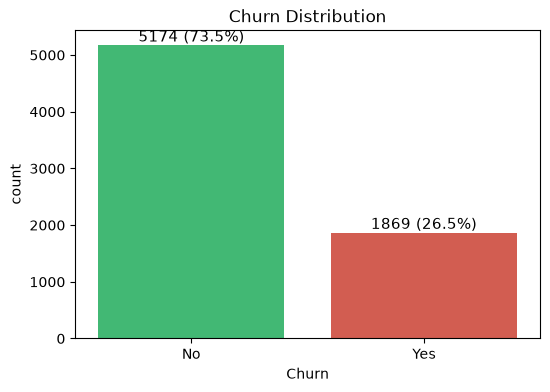

In [29]:
os.makedirs('EDA_plots', exist_ok=True)
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=Churn_df, palette=['#2ecc71','#e74c3c'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(Churn_df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Churn Distribution')
plt.savefig('EDA_plots/01_churn_distribution.png', bbox_inches='tight')
plt.show()

**2.Churn by Contract Type**

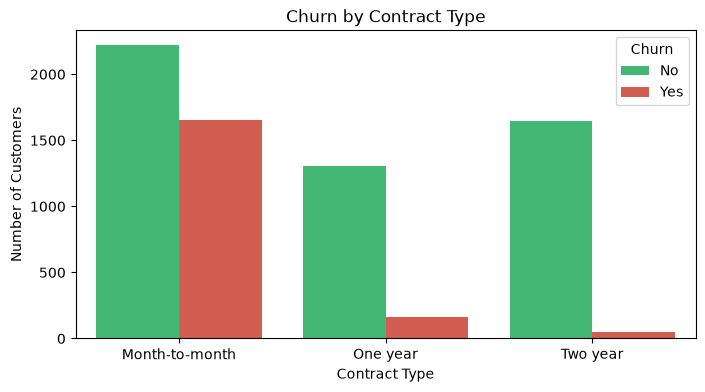

In [30]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='Contract', hue='Churn', data=Churn_df,
                   palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.savefig('EDA_plots/02_churn_by_contract.png', bbox_inches='tight')
plt.show()

**3.Churn by Internet Service**

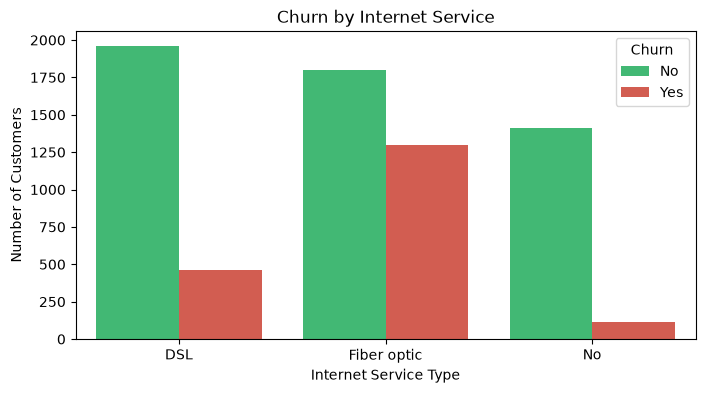

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(x='InternetService', hue='Churn', data=Churn_df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.savefig('EDA_plots/03_churn_by_internet.png', bbox_inches='tight')
plt.show()

**4.Churn by Payment Method**

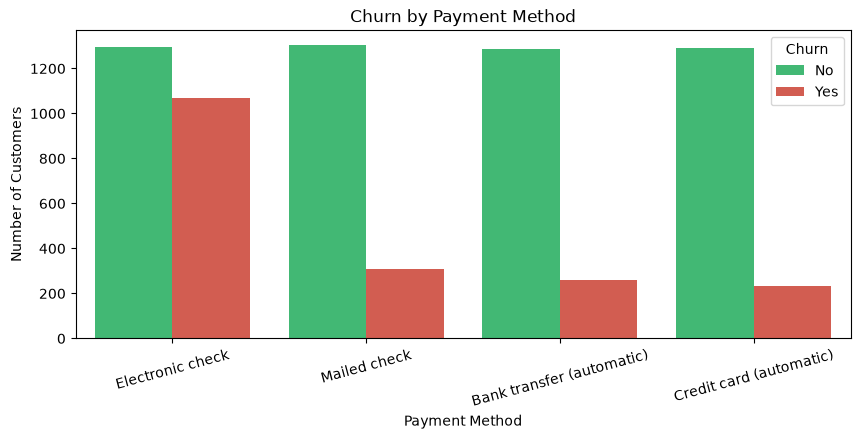

In [32]:
plt.figure(figsize=(10,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=Churn_df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.legend(title='Churn')
plt.savefig('EDA_plots/04_churn_by_payment.png', bbox_inches='tight')
plt.show()


**5.Tenure Distribution by Churn**

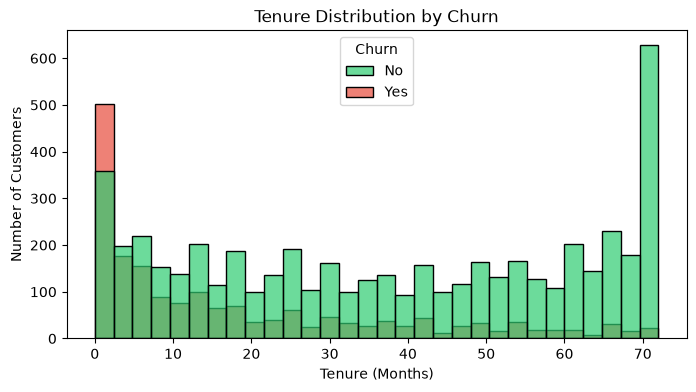

In [33]:
plt.figure(figsize=(8,4))
sns.histplot(data=Churn_df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.savefig('EDA_plots/05_tenure_distribution.png', bbox_inches='tight')
plt.show()

**6.Monthly Charges Distribution by Churn**

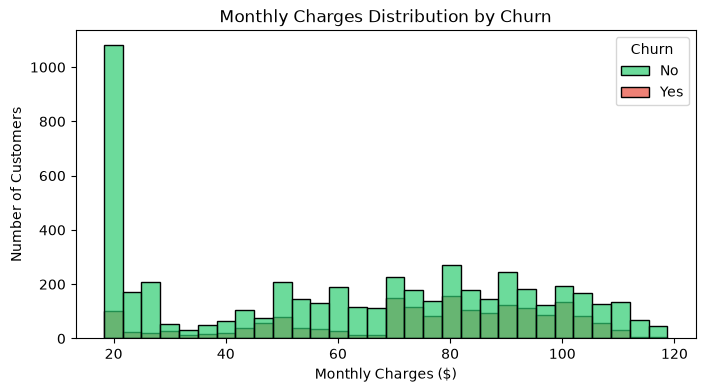

In [34]:
plt.figure(figsize=(8,4))
sns.histplot(data=Churn_df, x='MonthlyCharges', hue='Churn',
             bins=30, palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.savefig('EDA_plots/06_monthly_charges.png', bbox_inches='tight')
plt.show()

**7.Churn by Senior Citizen**

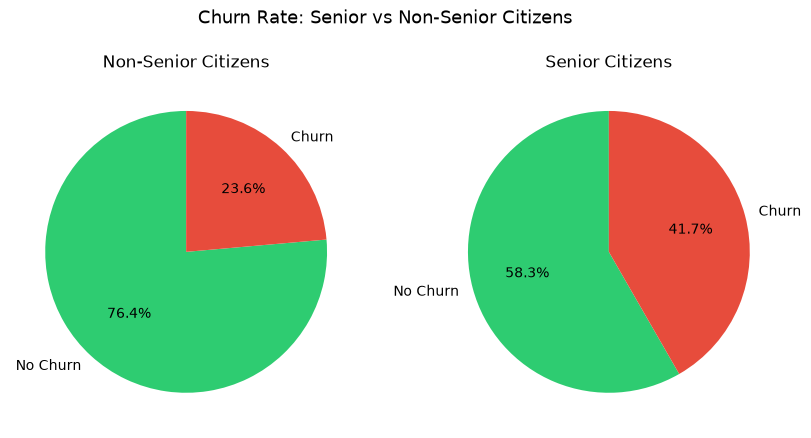

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = ['No Churn', 'Churn']
colors = ['#2ecc71', '#e74c3c']

for i, (val, title) in enumerate([(0, 'Non-Senior Citizens'),
                                   (1, 'Senior Citizens')]):
    group = Churn_df[Churn_df['SeniorCitizen'] == val]['Churn'].value_counts()
    axes[i].pie(group, labels=labels, colors=colors,
                autopct='%1.1f%%', startangle=90)
    axes[i].set_title(title)

plt.suptitle('Churn Rate: Senior vs Non-Senior Citizens', fontsize=13)
plt.savefig('EDA_plots/07_senior_citizen_pie.png', bbox_inches='tight')
plt.show()

**8.Total Services vs Churn**

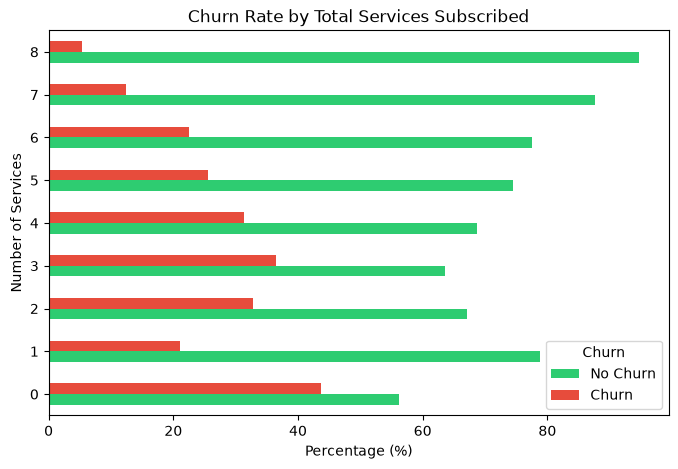

In [36]:
churn_by_services = Churn_df.groupby('total_services')['Churn']\
                    .value_counts(normalize=True)\
                    .mul(100).round(2)\
                    .unstack()

churn_by_services.plot(kind='barh', figsize=(8, 5),
                       color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Total Services Subscribed')
plt.xlabel('Percentage (%)')
plt.ylabel('Number of Services')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.savefig('EDA_plots/08_total_services_barh.png', bbox_inches='tight')
plt.show()

**9.Monthly Charges by Contract Type**

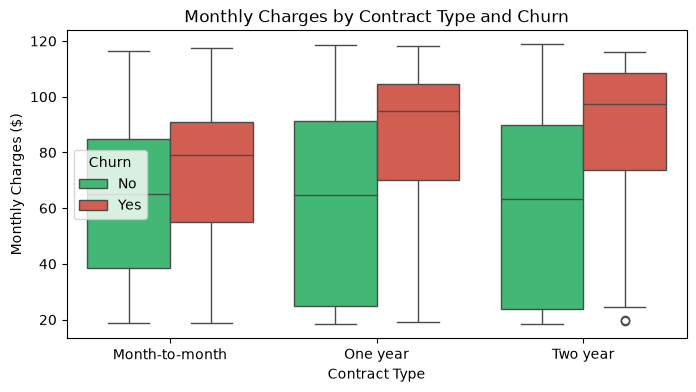

In [37]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn',
            data=Churn_df, palette=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges by Contract Type and Churn')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges ($)')
plt.savefig('EDA_plots/09_charges_by_contract.png', bbox_inches='tight')
plt.show()

**Conclusions for each chart**:
**Viz 1** — Churn Distribution
5174 customers stayed (73.5%) vs 1869 churned (26.5%). The dataset is imbalanced — this is why SMOTE is mandatory later.

**Viz 2** — Churn by Contract Type
Month-to-month customers churn massively compared to one-year and two-year contracts. Contract type is the single strongest predictor in the entire dataset. The company should push customers toward longer contracts.

**Viz 3** — Churn by Internet Service
Fiber optic customers churn the most despite — or because of — paying the highest prices. DSL customers are more stable. Customers with no internet barely churn at all.

**Viz 4** — Churn by Payment Method
Electronic check users churn at nearly 45% — the highest of any payment method. Automatic payment users (bank transfer and credit card) are the most loyal. Manual payment = less commitment.

**Viz 5** — Tenure Distribution by Churn
Churners are heavily concentrated in the first 12 months. The longer a customer stays, the less likely they are to leave. If you keep a customer past month 12 they are much safer.

**Viz 6** — Monthly Charges Distribution by Churn
Customers paying between $60–$100/month churn the most. Low-charge customers ($20–$40) are very stable. High monthly cost combined with a short-term contract is the danger zone.

**Viz 7** — Senior Citizen Pie Charts
Senior citizens have a 41.7% churn rate vs only 23.6% for non-seniors. Even though seniors are a small group (16% of customers), they are a high-risk segment that needs targeted retention.

**Viz 8** — Total Services Horizontal Bar
Customers with 0–2 services churn heavily. Customers with 5+ services barely churn at all. This validates the total_services feature we engineered in SQL — it is a strong predictor.

**Viz 9** — Boxplot Monthly Charges by Contract
Month-to-month churners have the highest and widest spread of monthly charges. Two-year customers have low and consistent charges regardless of churn status. High charges + no long-term commitment = highest churn risk.

# **4.Feature Engineering & Encoding**

**Label Encoding**

In [38]:
Churn_df['gender'] = Churn_df['gender'].map({'Female': 0, 'Male': 1})
print("Gender encoded")
print(Churn_df['gender'].head())

Gender encoded
0    0
1    1
2    1
3    1
4    0
Name: gender, dtype: int64


**Binary Encoding**

In [39]:
#target Col
Churn_df['Churn'] = Churn_df['Churn'].map({'Yes': 1, 'No': 0})
print("Target column encoded")
print(Churn_df['Churn'].value_counts())

Target column encoded
Churn
0    5174
1    1869
Name: count, dtype: int64


In [40]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in binary_cols:
    Churn_df[col] = Churn_df[col].map({'Yes': 1, 'No': 0,
                                        'No internet service': 0,
                                        'No phone service': 0})


In [41]:
print("Binary columns encoded")
print(Churn_df[binary_cols].head())

Binary columns encoded
   Partner  Dependents  PhoneService  PaperlessBilling  OnlineSecurity  \
0        1           0             0                 1               0   
1        0           0             1                 0               1   
2        0           0             1                 1               1   
3        0           0             0                 0               1   
4        0           0             1                 1               0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  
0             1                 0            0            0                0  
1             0                 1            0            0                0  
2             1                 0            0            0                0  
3             0                 1            1            0                0  
4             0                 0            0            0                0  


**One-hot Encoding**

In [42]:
multi_cols = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines']

Churn_df = pd.get_dummies(Churn_df, columns=multi_cols, drop_first=False)

In [43]:
print("One-Hot Encoding done")
print("New shape after encoding:", Churn_df.shape)
print(Churn_df.columns.tolist())

One-Hot Encoding done
New shape after encoding: (7043, 30)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'total_services', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes']


**Correlation Analysis**

1.Full Correlation matrix with heatmap

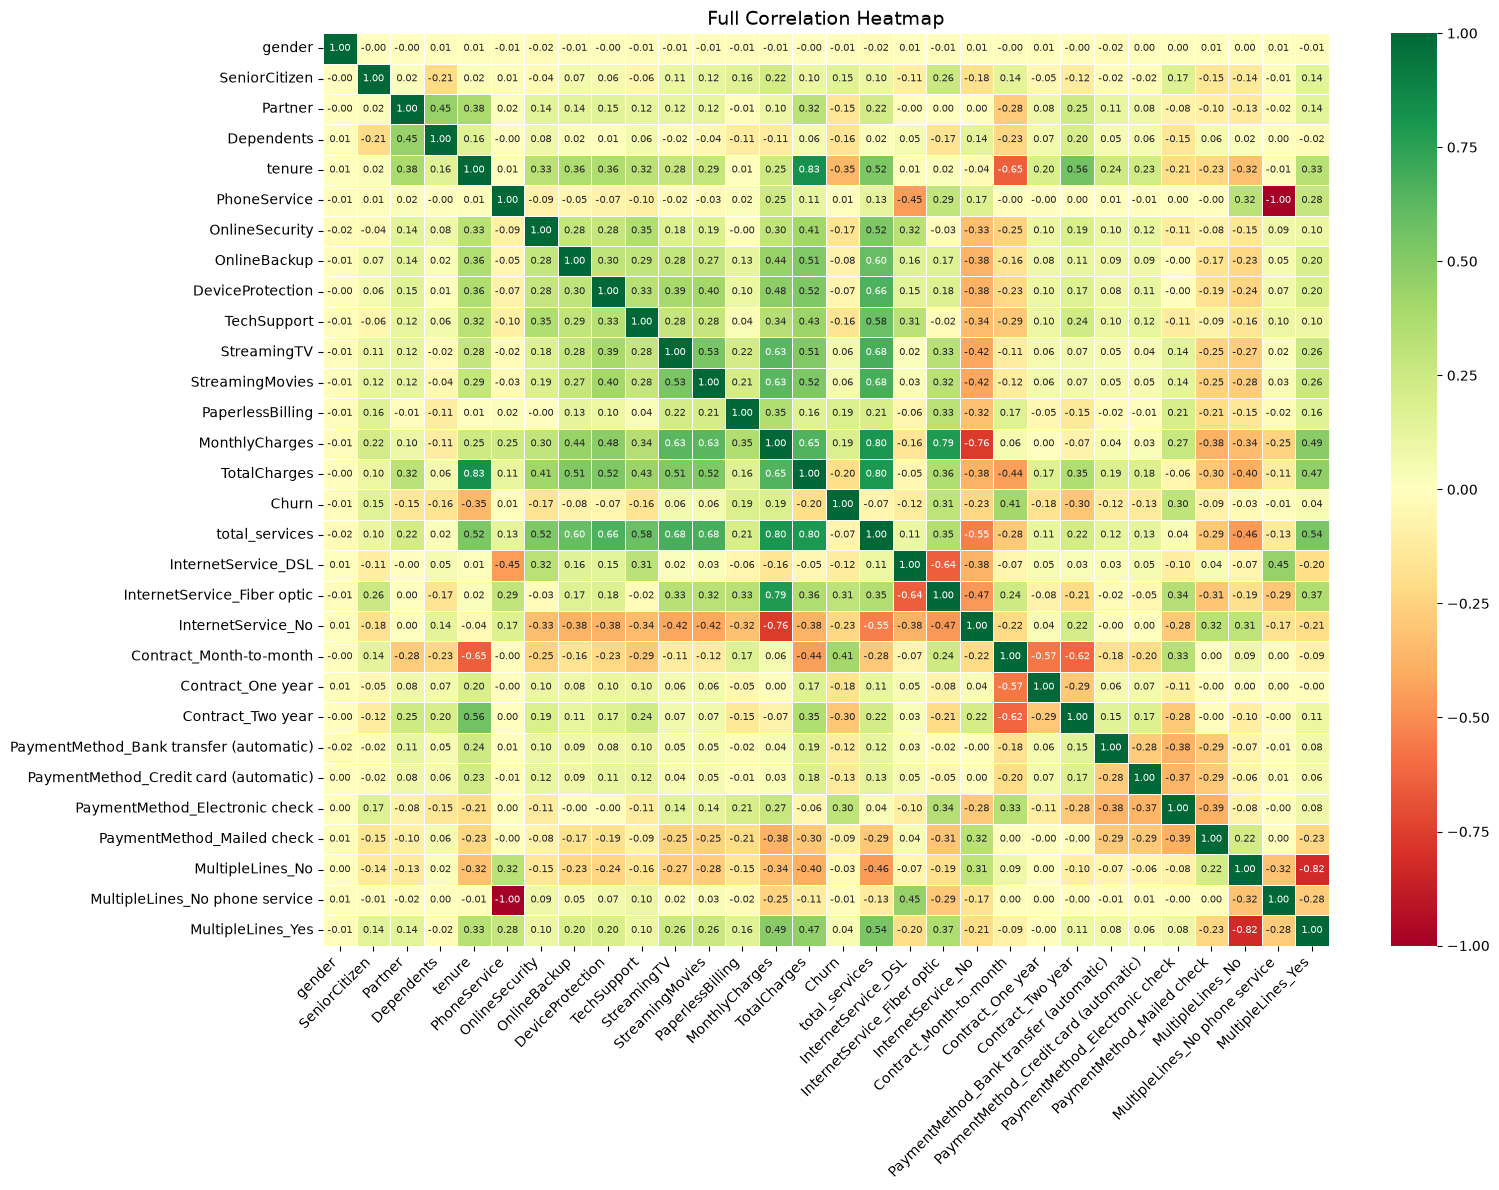

In [44]:
corr_matrix = Churn_df.corr()
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            #  mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Full Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('EDA_plots/10_full_heatmap.png', bbox_inches='tight')
plt.show()

2.Correlation with target

In [45]:
churn_corr = corr_matrix['Churn'].drop('Churn')\
             .sort_values(ascending=False)

print("Correlation with Churn (sorted)")
print(churn_corr.round(3))

Correlation with Churn (sorted)
Contract_Month-to-month                    0.405
InternetService_Fiber optic                0.308
PaymentMethod_Electronic check             0.302
MonthlyCharges                             0.193
PaperlessBilling                           0.192
SeniorCitizen                              0.151
StreamingTV                                0.063
StreamingMovies                            0.061
MultipleLines_Yes                          0.040
PhoneService                               0.012
gender                                    -0.009
MultipleLines_No phone service            -0.012
MultipleLines_No                          -0.033
DeviceProtection                          -0.066
total_services                            -0.067
OnlineBackup                              -0.082
PaymentMethod_Mailed check                -0.092
PaymentMethod_Bank transfer (automatic)   -0.118
InternetService_DSL                       -0.124
PaymentMethod_Credit card (automatic)

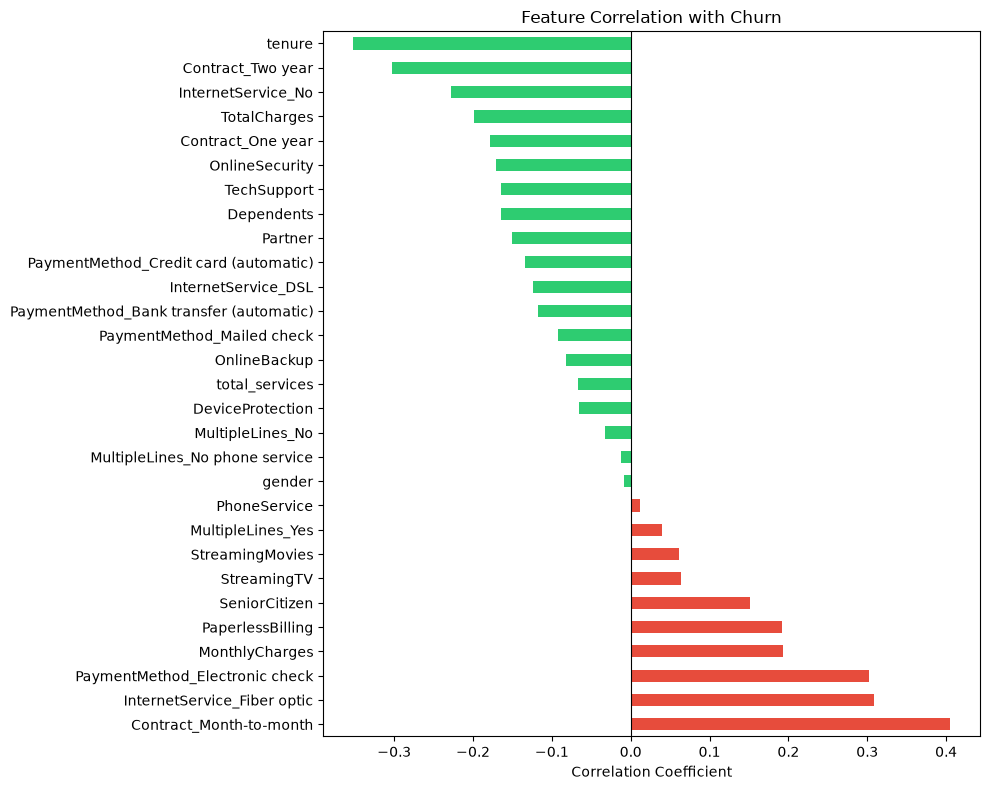

In [46]:
plt.figure(figsize=(10, 8))
churn_corr.plot(kind='barh',
                color=churn_corr.map(lambda x: '#e74c3c' if x > 0 else '#2ecc71'))
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('EDA_plots/11_churn_correlation_bar.png', bbox_inches='tight')
plt.show()

3.Drop Week Features (0.05 is the threshold)

In [47]:
weak_features = churn_corr[abs(churn_corr) < 0.05].index.tolist()
print("\nWeak features to drop:", weak_features)


Weak features to drop: ['MultipleLines_Yes', 'PhoneService', 'gender', 'MultipleLines_No phone service', 'MultipleLines_No']


In [48]:
Churn_df.drop(columns=weak_features, inplace=True)
print("Weak features dropped")
print("Final shape:", Churn_df.shape)

Weak features dropped
Final shape: (7043, 25)


# **5.Handling Class Imbalance**

In [49]:
features  = Churn_df.drop('Churn', axis=1)
churn_label = Churn_df['Churn']


Train / Test Split

In [50]:
features_train, features_test, churn_label_train, churn_label_test = train_test_split(
    features, churn_label,
    test_size=0.2,
    random_state=42,
    stratify=churn_label
)

In [51]:
print("Before SMOTE:")
print(churn_label_train.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


#**6.Feature Scaling**

In [52]:
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = MinMaxScaler()
features_train[continuous_cols] = scaler.fit_transform(features_train[continuous_cols])
features_test[continuous_cols] = scaler.transform(features_test[continuous_cols])

os.makedirs('artifacts', exist_ok=True)
joblib.dump(scaler, 'artifacts/minmax_scaler.pkl')
print('Scaler fit on training set and saved to artifacts/minmax_scaler.pkl')
features_train[continuous_cols].describe()

Scaler fit on training set and saved to artifacts/minmax_scaler.pkl


,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000
mean,0.451182,0.463677,0.264754
std,0.341233,0.300330,0.262436
min,0.000000,0.000000,0.000000
25%,0.125000,0.172023,0.046400
50%,0.402778,0.519183,0.160617
75%,0.763889,0.713503,0.441671
max,1.000000,1.000000,1.000000


Apply SMOTE

In [53]:
smote = SMOTE(random_state=42)
features_train_smote, churn_label_train_smote = smote.fit_resample(features_train, churn_label_train)

In [54]:
print("After SMOTE:")
print(churn_label_train_smote.value_counts())

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


#**Export Artifacts**


Saving for the second milestone to load it directly(x_train ,y_train ,x_test , y_test , minmax_scaler.pkl , feature_columns)

In [55]:
os.makedirs('artifacts', exist_ok=True)

# Training set
features_train_smote.to_csv('artifacts/X_train.csv', index=False)
churn_label_train_smote.to_csv('artifacts/y_train.csv', index=False)

In [56]:
# Test set
features_test.to_csv('artifacts/X_test.csv', index=False)
churn_label_test.to_csv('artifacts/y_test.csv', index=False)

In [ ]:
# Final feature column order (needed for the API)
with open('artifacts/feature_columns.json', 'w') as f:
    json.dump(list(features_train_smote.columns), f, indent=2)

print('Artifacts exported to ./artifacts/:')
for fname in os.listdir('artifacts'):
    print(' -', fname)

Artifacts exported to ./artifacts/:
 - feature_columns.json
 - minmax_scaler.pkl
 - X_test.csv
 - X_train.csv
 - y_test.csv
 - y_train.csv


: 